In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os

In [2]:
full_df = pd.read_parquet('../sorted_data.parquet')
df_popularity = full_df.groupby(['user_id', 'track_id']).count()

In [3]:
df_popularity = df_popularity.rename(columns={'ts':'pop'})
df_pop_user = df_popularity.groupby('user_id').sum()
df_pop_item = df_popularity.groupby('track_id').sum()

In [4]:
data_path = '../results'

models = ['original', 'extended', 'extendedDoubleBase', 'extendedDoubleEmb', 'extendedDoubleEmbFreeze']
# models = ['original']

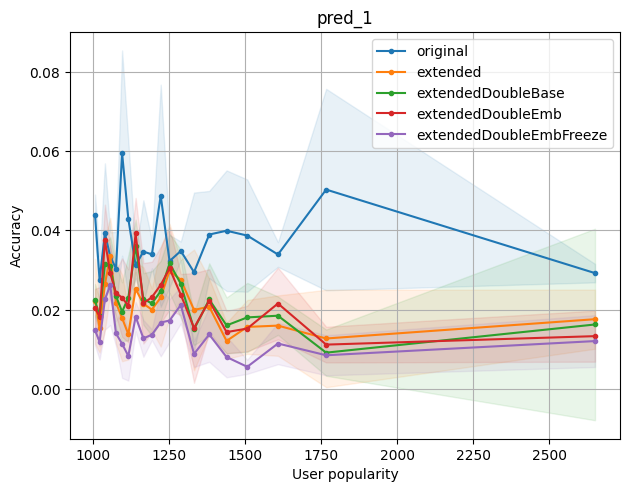

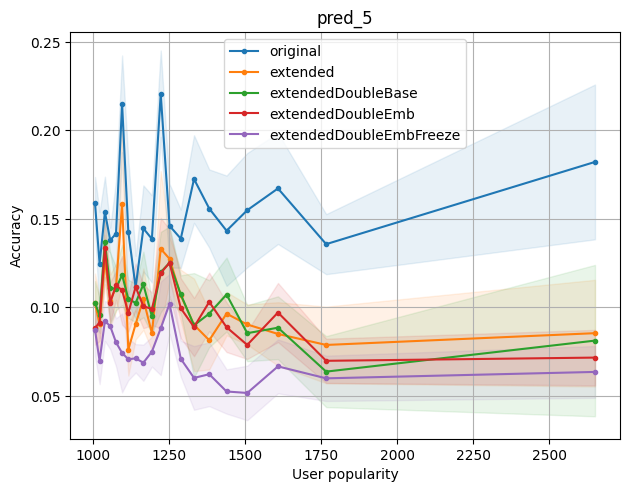

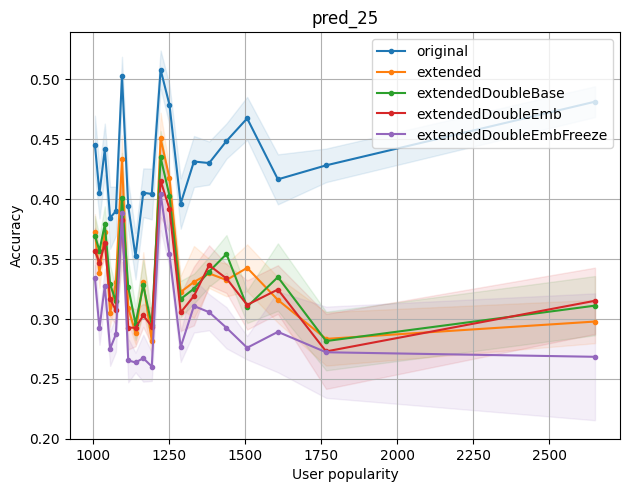

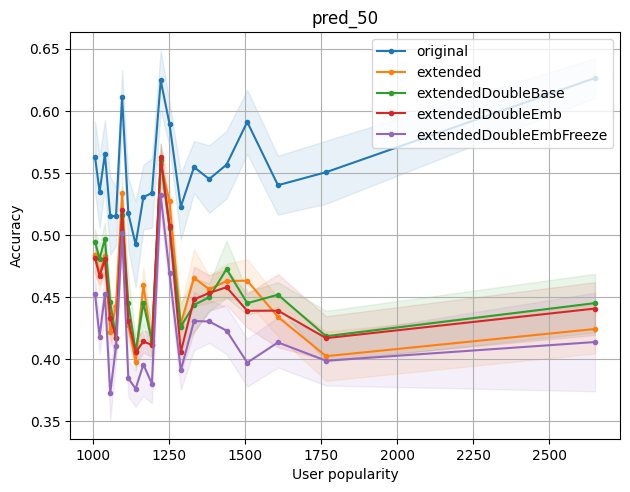

In [5]:
wanted_cols = [1, 5, 25, 50]
# wanted_cols = [50]
n_bins = 20


for wanted_col in wanted_cols:
    plt.figure()
    for m in models:
        df_list = []
        dir_path = f'{data_path}/{m}'
        for f in os.listdir(dir_path):
            path = os.path.join(dir_path, f)
            if path.endswith('.csv'):
                df = pd.read_csv(path)
                df['split'] = f
                df_list.append(df)
    
        df = pd.concat(df_list, ignore_index=True)
    
        df = df.rename(columns={'userId': 'user_id', 'trackId': 'track_id'})
    
        pred_cols = [f"pred_{i}" for i in range(1, 50 + 1)]
        preds = df[pred_cols].to_numpy()
        
        true_items = df['track_id'].to_numpy()
    
        hits = (preds == true_items[:, None])
    
        cum_hits = np.cumsum(hits.astype(int), axis=1)
    
        df[pred_cols] = cum_hits
    
        df['count'] = 1

    
        df = df.merge(df_pop_user, on=['user_id'], how="left")
        df = df.sort_values('pop', ascending=False)

        df["pop_bin"] = pd.qcut(
                        df["pop"],
                        q=n_bins,
                        duplicates="drop"
                    )

        df['correct'] = df[f'pred_{wanted_col}']
        summary = df.groupby(['pop_bin', 'split'], observed=True)[['count', 'correct']].sum()

        summary['accuracy'] = summary['correct'] / summary['count']

        summary = summary.groupby('pop_bin', observed=False)['accuracy'].agg(['mean', 'std'])

        summary["pop_center"] = [0.5 * (x.left + x.right) for x in summary.index.values]

        
        line, = plt.plot(summary['pop_center'], summary['mean'], label=f'{m}', marker='o', markersize=3)

        
        plt.fill_between(
            summary['pop_center'],
            summary['mean'] - 1.96*summary['std'],
            summary['mean'] + 1.96*summary['std'],
            alpha=0.1,
            color=line.get_color()
        )
        
    plt.xlabel("User popularity")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.grid()
    # plt.ylim([-0.02,0.22])
    plt.title(f'pred_{wanted_col}')
    plt.show()

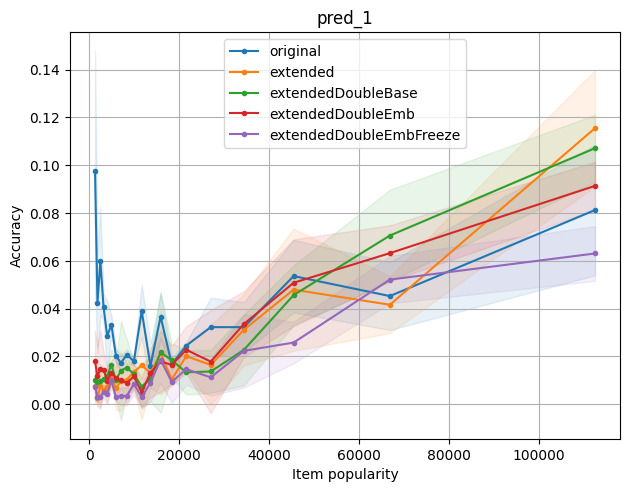

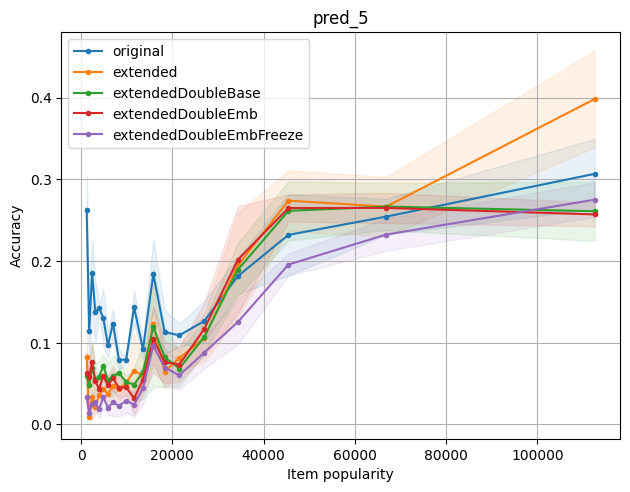

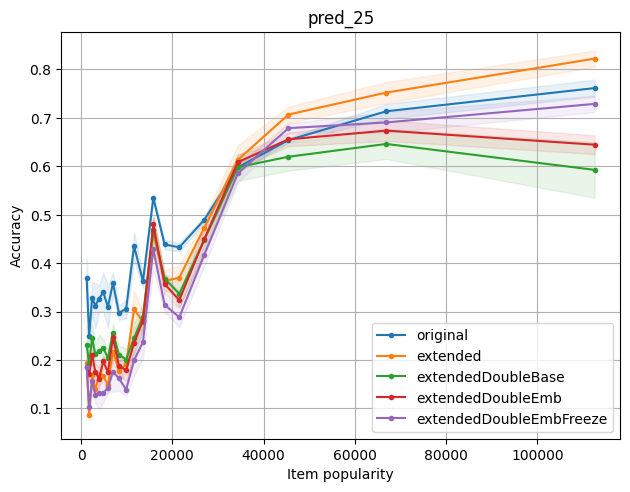

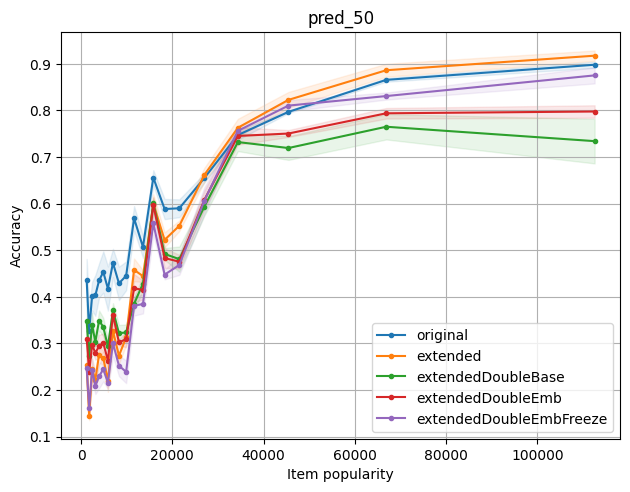

In [6]:
wanted_cols = [1, 5, 25, 50]
# wanted_cols = [50]
n_bins = 20


for wanted_col in wanted_cols:
    plt.figure()
    for m in models:
        df_list = []
        dir_path = f'{data_path}/{m}'
        for f in os.listdir(dir_path):
            path = os.path.join(dir_path, f)
            if path.endswith('.csv'):
                df = pd.read_csv(path)
                df['split'] = f
                df_list.append(df)
    
        df = pd.concat(df_list, ignore_index=True)
    
        df = df.rename(columns={'userId': 'user_id', 'trackId': 'track_id'})
    
        pred_cols = [f"pred_{i}" for i in range(1, 50 + 1)]
        preds = df[pred_cols].to_numpy()
        
        true_items = df['track_id'].to_numpy()
    
        hits = (preds == true_items[:, None])
    
        cum_hits = np.cumsum(hits.astype(int), axis=1)
    
        df[pred_cols] = cum_hits
    
        df['count'] = 1

    
        df = df.merge(df_pop_item, on=['track_id'], how="left")
        df = df.sort_values('pop', ascending=False)

        df["pop_bin"] = pd.qcut(
                        df["pop"],
                        q=n_bins,
                        duplicates="drop"
                    )

        df['correct'] = df[f'pred_{wanted_col}']
        summary = df.groupby(['pop_bin', 'split'], observed=True)[['count', 'correct']].sum()

        summary['accuracy'] = summary['correct'] / summary['count']

        summary = summary.groupby('pop_bin', observed=False)['accuracy'].agg(['mean', 'std'])

        summary["pop_center"] = [0.5 * (x.left + x.right) for x in summary.index.values]

        
        line, = plt.plot(summary['pop_center'], summary['mean'], label=f'{m}', marker='o', markersize=3)

        
        plt.fill_between(
            summary['pop_center'],
            summary['mean'] - 1.96*summary['std'],
            summary['mean'] + 1.96*summary['std'],
            alpha=0.1,
            color=line.get_color()
        )
        
    plt.xlabel("Item popularity")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.grid()
    # plt.ylim([-0.02,0.22])
    plt.title(f'pred_{wanted_col}')
    plt.show()